# Demo

A demostration script for the ECLYPSE network simulator extension.

This script validates the implementation of the queuing model,
physical link parameters, and routing tables by simulating a "bottleneck"
scenario.

It sets up a topology:

- Sensor → Gateway
- Gateway → R1
- Gateway → R2
- R1 → R2
- R1 → R3
- R2 → R3
- R3 → Cloud

It defines traffic flows,
and measures the end-to-end packet delays to demonstrate the emergence of
queuing congestion.

In [1]:
import time
from eclypse.remote.service import Service
from network import Network
from network_application import NetworkAwareApplication
from eclypse.simulation.config import SimulationConfig
import pandas as pd
import matplotlib.pyplot as plt
import random
random.seed(42)

In [ ]:
from eclypse.placement.strategies import StaticStrategy
from traffic_event import TrafficRoutingEvent
from packet_generation import PacketGenerationEvent
from eclypse.simulation import Simulation

print("1. Setting up Infrastructure...")
infra = Network("IoT_Network")

infrastructure_nodes = ["Sensor", "Gateway", "R1", "R2", "R3", "Cloud"]
for node in infrastructure_nodes:
    infra.add_node(node)

# Access Link (Sensor -> Gateway): 100 Mbps, 1 km
infra.add_edge("Sensor", "Gateway", bandwidth_mbps=100, length_km=1)

# Core Network Links: 50 Mbps
infra.add_edge("Gateway", "R1", bandwidth_mbps=50, length_km=5)
infra.add_edge("Gateway", "R2", bandwidth_mbps=50, length_km=5)
infra.add_edge("R1", "R2", bandwidth_mbps=50, length_km=2)
infra.add_edge("R1", "R3", bandwidth_mbps=50, length_km=10)
infra.add_edge("R2", "R3", bandwidth_mbps=50, length_km=10)

# Bottleneck Link (R3 -> Cloud): 10 Mbps, 50 km 
infra.add_edge("R3", "Cloud", bandwidth_mbps=10, length_km=50)

# Installation of shortest path routes (default behavior)
infra.install_shortest_path_routes()


print("2. Setting up Application (Video Stream)...")
app = NetworkAwareApplication("VideoApp")

app.add_node("Sensor1", cpu=0, ram=0, gpu=0, storage=0, availability=0.0)
app.add_node("Cloud1", cpu=0, ram=0, gpu=0, storage=0, availability=0.0)


app.add_edge("Sensor1", "Cloud1", packet_size_bytes=1500, packets_per_tick=1, bandwidth=0)

traffic_event = TrafficRoutingEvent(tick_duration_s=0.0005)
packet_event = PacketGenerationEvent()

sim_config = SimulationConfig(
        seed=42,
        max_steps=100,
        step_every_ms=1000, 
        events=[packet_event, traffic_event],
        include_default_metrics=False,
        remote=False
    )

print("3. Initializing Simulation...")
sim = Simulation(infra, simulation_config=sim_config)

strategy = StaticStrategy({
    "Sensor1": "Sensor",
    "Cloud1": "Cloud"
})
sim.register(app, placement_strategy=strategy)

sim.start()
sim.wait()

df_results = traffic_event.get_dataframe()

1. Setting up Infrastructure...
[OSPF] NumPy routing matrix (6x6) recalculated.
2. Setting up Application (Video Stream)...
Added edge flow Sensor1->Cloud1: 1 pkt/tick, size 1500B
3. Initializing Simulation...
16:27:26.763 | INFO | SimulationConfig - Target path exists; writing to /home/davide/eclypse-sim-20260504_162726 instead
16:27:26.791 | ECLYPSE | PlacementManager - Placement established | app=VideoApp | mapping={'Sensor1': 'Sensor', 'Cloud1': 'Cloud'}
[DEBUG GEN] Tick 1: App 'VideoApp' has generated 1 packets.
[DEBUG ROUTER] Routing 1 packets in progress...
16:27:26.791 | ECLYPSE | Simulation - Simulation configuration | infrastructure=IoT_Network | path=/home/davide/eclypse-sim-20260504_162726 | remote=False | step_every_ms=1000 | max_steps=100 | seed=42 | report_format=csv | report_backend=pandas | log_level=ECLYPSE | log_to_file=False | include_default_metrics=False
16:27:26.792 | ECLYPSE | Simulation - Simulation started.
16:27:26.791 | ECLYPSE | Simulation - Simulation step

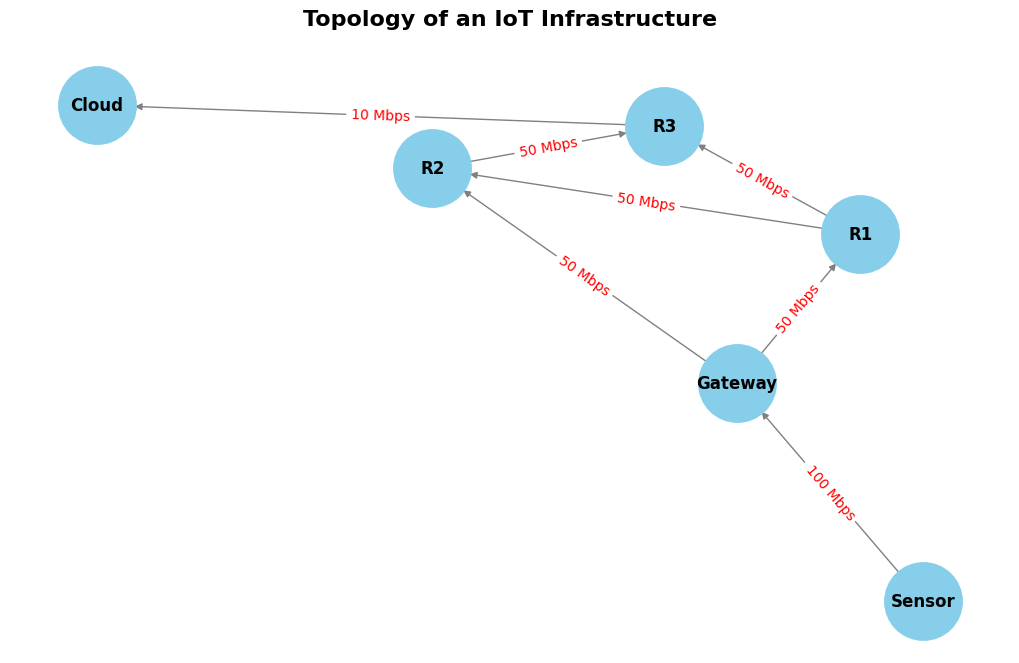

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a NetworkX graph from the infrastructure
plt.figure(figsize=(10, 6))

# Calculate the positions of the nodes using the spring layout algorithm 
pos = nx.spring_layout(infra, seed=42) 

# Draw the network with custom styling
nx.draw(
    infra, 
    pos, 
    with_labels=True, 
    node_color='skyblue', 
    node_size=3000, 
    font_size=12, 
    font_weight='bold', 
    edge_color='gray',
    linewidths=2
)

# print the bandwidth on the edges using the 'bandwidth_mbps' attribute
edge_labels = nx.get_edge_attributes(infra, 'bandwidth_mbps')
if edge_labels:
    # add "Mbps" to the bandwidth values for better readability
    formatted_labels = {edge: f"{bw} Mbps" for edge, bw in edge_labels.items()}
    nx.draw_networkx_edge_labels(infra, pos, edge_labels=formatted_labels, font_color='red')

plt.title("Topology of an IoT Infrastructure", fontsize=16, fontweight='bold', pad=20)
plt.axis('off') # Hide axes for better visualization
plt.show()

The simulation has recorded 100 packets delivered!


,Tick,Packet_ID,App,Src,Dst,Start_Time,End_Time,Total_Delay_ms,Hops
0,1,1,VideoApp,Sensor,Cloud,0.0005,0.004809,4.309444,"[HopInfo(hop='Sensor->Gateway', processing_ms=..."
1,2,2,VideoApp,Sensor,Cloud,0.0010,0.005061,4.061072,"[HopInfo(hop='Sensor->Gateway', processing_ms=..."
2,3,3,VideoApp,Sensor,Cloud,0.0015,0.005460,3.959764,"[HopInfo(hop='Sensor->Gateway', processing_ms=..."
3,4,4,VideoApp,Sensor,Cloud,0.0020,0.007142,5.141840,"[HopInfo(hop='Sensor->Gateway', processing_ms=..."
4,5,5,VideoApp,Sensor,Cloud,0.0025,0.008612,6.111976,"[HopInfo(hop='Sensor->Gateway', processing_ms=..."
...,...,...,...,...,...,...,...,...,...
95,96,96,VideoApp,Sensor,Cloud,0.0480,0.111550,63.549707,"[HopInfo(hop='Sensor->Gateway', processing_ms=..."
96,97,97,VideoApp,Sensor,Cloud,0.0485,0.112472,63.972248,"[HopInfo(hop='Sensor->Gateway', processing_ms=..."
97,98,98,VideoApp,Sensor,Cloud,0.0490,0.112919,63.919364,"[HopInfo(hop='Sensor->Gateway', processing_ms=..."
98,99,99,VideoApp,Sensor,Cloud,0.0495,0.113016,63.515646,"[HopInfo(hop='Sensor->Gateway', processing_ms=..."


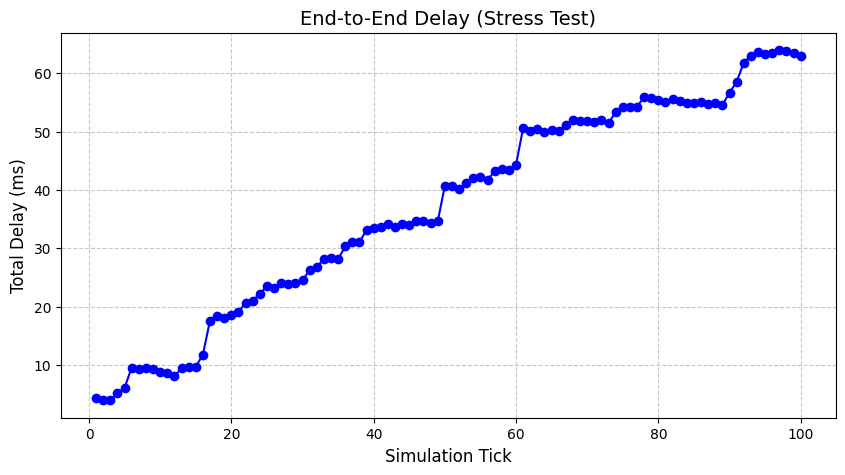

In [4]:
import matplotlib.pyplot as plt

# We extract data by piercing the decorator wrapper
df_results = traffic_event.get_dataframe()
print(f"The simulation has recorded {len(df_results)} packets delivered!")

if not df_results.empty:
    # We show the table with the results
    display(df_results)

    # Let's create the End-to-End Delay graph
    plt.figure(figsize=(10, 5))
    
    # X-Axis = Tick it started in, Y-Axis = Delay in milliseconds
    plt.plot(df_results["Tick"], df_results["Total_Delay_ms"], marker='o', linestyle='-', color='b')
    
    plt.title("End-to-End Delay (Stress Test)", fontsize=14)
    plt.xlabel("Simulation Tick", fontsize=12)
    plt.ylabel("Total Delay (ms)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.show()
else:
    print("No packets were recorded.")

In [5]:
all_events = []

if 'Hops' in df_results.columns:
    # We extract every single jump from the DataFrame
    for index, row in df_results.iterrows():
        packet_id = row['Packet_ID']
        
        # If the packet has traveled, we extract the individual hops
        if isinstance(row['Hops'], list):
            for hop in row['Hops']:
                
                all_events.append({
                    'time': hop.arrival_at_next,
                    'packet_id': packet_id,
                    'event': f"Link: {hop.hop:^17} | Status: FINISHED | Queue: {hop.queue_length:>2} pkts"
                })

    # We sort all events by chronological order 
    all_events_sorted = sorted(all_events, key=lambda x: x['time'])
    
    # We print all events in order
    print("HOP CHRONOLOGICAL LOG")
    for ev in all_events_sorted:
        print(f"[{ev['time']:10.6f}s] | Packet: {ev['packet_id']:<5} | {ev['event']}")
else:
    print("Error: The column 'Hops' is not present in the DataFrame!")

HOP CHRONOLOGICAL LOG
[  0.000682s] | Packet: 1     | Link:  Sensor->Gateway  | Status: FINISHED | Queue:  0 pkts
[  0.001048s] | Packet: 1     | Link:    Gateway->R1    | Status: FINISHED | Queue:  0 pkts
[  0.001118s] | Packet: 2     | Link:  Sensor->Gateway  | Status: FINISHED | Queue:  0 pkts
[  0.001277s] | Packet: 1     | Link:      R1->R3       | Status: FINISHED | Queue:  0 pkts
[  0.001464s] | Packet: 2     | Link:    Gateway->R1    | Status: FINISHED | Queue:  0 pkts
[  0.001647s] | Packet: 3     | Link:  Sensor->Gateway  | Status: FINISHED | Queue:  0 pkts
[  0.001824s] | Packet: 3     | Link:    Gateway->R1    | Status: FINISHED | Queue:  0 pkts
[  0.002060s] | Packet: 2     | Link:      R1->R3       | Status: FINISHED | Queue:  0 pkts
[  0.002329s] | Packet: 4     | Link:  Sensor->Gateway  | Status: FINISHED | Queue:  0 pkts
[  0.002479s] | Packet: 3     | Link:      R1->R3       | Status: FINISHED | Queue:  1 pkts
[  0.002704s] | Packet: 5     | Link:  Sensor->Gateway  | 

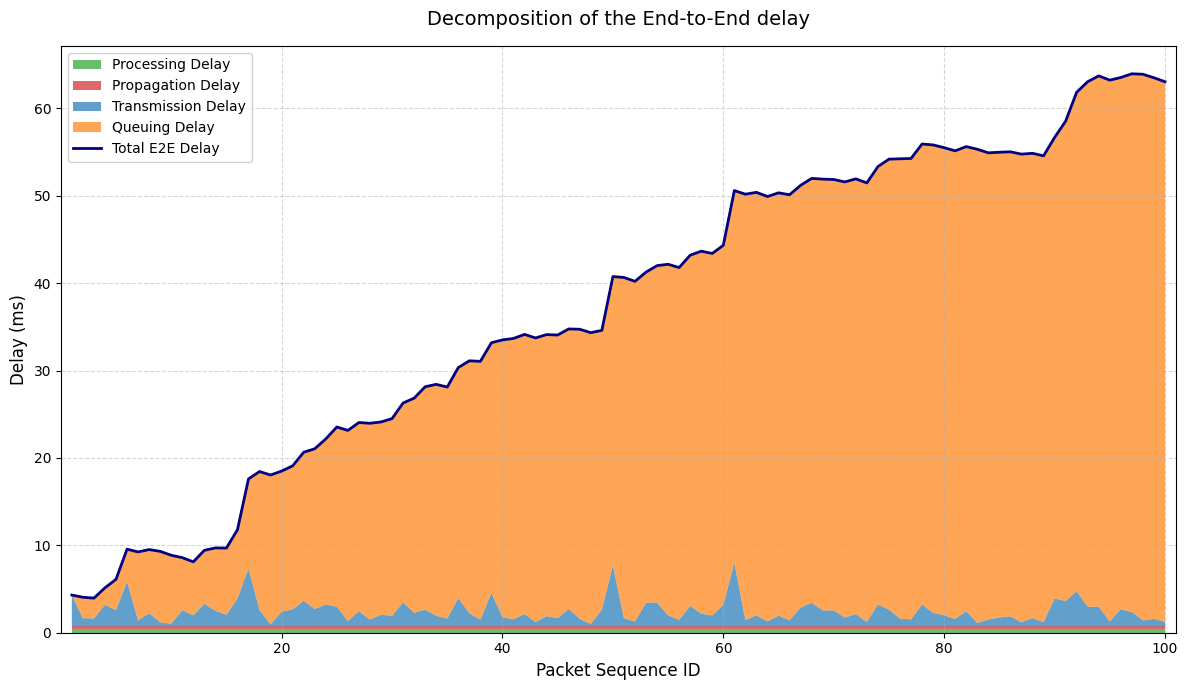


Breakdown of the last packet (ID 100):
- Processing:   0.40 ms
- Propagation:  0.33 ms
- Transmission: 0.50 ms
- Queuing:      61.83 ms
--------------------------------
= TOTAL:        63.06 ms


In [6]:
import matplotlib.pyplot as plt

# Helper function to sum a specific metric across all hops of a packet
def sum_metric_all_hops(hops_list, metric_name):
    if not isinstance(hops_list, list): return 0.0
    return sum(getattr(hop, metric_name, 0.0) for hop in hops_list)

df = df_results 

# Find automatically the name of the hops column
hops = 'Hops' if 'Hops' in df.columns else 'Hops_Details'

# Creation of new columns with the sum of each metric across all hops
df['Total_Proc_ms'] = df[hops].apply(lambda x: sum_metric_all_hops(x, 'processing_ms'))
df['Total_Prop_ms'] = df[hops].apply(lambda x: sum_metric_all_hops(x, 'propagation_ms'))
df['Total_Trans_ms'] = df[hops].apply(lambda x: sum_metric_all_hops(x, 'transmission_ms'))
df['Total_Queue_ms'] = df[hops].apply(lambda x: sum_metric_all_hops(x, 'queue_ms'))

# Creation of the graph
plt.figure(figsize=(12, 7))

# Create the stackplot for the breakdown of delays
plt.stackplot(
    df['Packet_ID'],
    df['Total_Proc_ms'],
    df['Total_Prop_ms'],
    df['Total_Trans_ms'],
    df['Total_Queue_ms'],
    labels=['Processing Delay', 'Propagation Delay', 'Transmission Delay', 'Queuing Delay'],
    colors=['#2ca02c', '#d62728', '#1f77b4', '#ff7f0e'], 
    alpha=0.7
)

# Upper line to mark the Total E2E Delay
plt.plot(df['Packet_ID'], df['Total_Delay_ms'], color='navy', linewidth=2, label='Total E2E Delay')

plt.title("Decomposition of the End-to-End delay", fontsize=14, pad=15)
plt.xlabel("Packet Sequence ID", fontsize=12)
plt.ylabel("Delay (ms)", fontsize=12)
plt.legend(loc='upper left', framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.5)

plt.margins(x=0.01)
plt.tight_layout()

plt.show()

# Final print to show the breakdown of the last packet
last_pkt = df.iloc[-1]
print(f"\nBreakdown of the last packet (ID {last_pkt['Packet_ID']}):")
print(f"- Processing:   {last_pkt['Total_Proc_ms']:.2f} ms")
print(f"- Propagation:  {last_pkt['Total_Prop_ms']:.2f} ms")
print(f"- Transmission: {last_pkt['Total_Trans_ms']:.2f} ms")
print(f"- Queuing:      {last_pkt['Total_Queue_ms']:.2f} ms")
print(f"--------------------------------")
print(f"= TOTAL:        {last_pkt['Total_Delay_ms']:.2f} ms")

# Failure recovery

In [7]:
import time
from eclypse.remote.service import Service
from network import Network
from network_application import NetworkAwareApplication
from eclypse.simulation.config import SimulationConfig
import pandas as pd
import matplotlib.pyplot as plt
import random
random.seed(42)

In [ ]:
from eclypse.placement.strategies import StaticStrategy
from traffic_event import TrafficRoutingEvent
from packet_generation import PacketGenerationEvent
from eclypse.network.fault_injection import FaultInjectionEvent
from eclypse.simulation import Simulation

print("1. Setting up Infrastructure...")
infra = Network("IoT_Network")

infrastructure_nodes = ["Sensor", "Gateway", "R1", "R2", "R3", "Cloud"]
for node in infrastructure_nodes:

    infra.add_node(node)

# Access Link (Sensor -> Gateway): 100 Mbps, 1 km
infra.add_edge("Sensor", "Gateway", bandwidth_mbps=100, length_km=1)

# Core Network Links: 50 Mbps
infra.add_edge("Gateway", "R1", bandwidth_mbps=50, length_km=5)
infra.add_edge("Gateway", "R2", bandwidth_mbps=50, length_km=5)
infra.add_edge("R1", "R2", bandwidth_mbps=50, length_km=2)
infra.add_edge("R1", "R3", bandwidth_mbps=50, length_km=10)
infra.add_edge("R2", "R3", bandwidth_mbps=50, length_km=10)

# Bottleneck Link (R3 -> Cloud): 10 Mbps, 50 km 
infra.add_edge("R3", "Cloud", bandwidth_mbps=10, length_km=50)

# Installation of shortest path routes (default behavior)
infra.install_shortest_path_routes()


print("2. Setting up Application (Video Stream)...")
app = NetworkAwareApplication("VideoApp")

app.add_node("Sensor1", cpu=0, ram=0, gpu=0, storage=0, availability=0.0)
app.add_node("Cloud1", cpu=0, ram=0, gpu=0, storage=0, availability=0.0)

app.add_edge("Sensor1", "Cloud1", packet_size_bytes=1500, packets_per_tick=1, bandwidth=0)

traffic_event = TrafficRoutingEvent(tick_duration_s=0.0005)
packet_event = PacketGenerationEvent()
sim_config = SimulationConfig(
        seed=42,
        max_steps=100,
        step_every_ms=1000, 
        events=[packet_event, traffic_event, FaultInjectionEvent],
        include_default_metrics=False,
        remote=False
    )

print("3. Initializing Simulation...")
sim = Simulation(infra, simulation_config=sim_config)

strategy = StaticStrategy({
    "Sensor1": "Sensor",
    "Cloud1": "Cloud"
})
sim.register(app, placement_strategy=strategy)

sim.start()
sim.wait()

df_results = traffic_event.get_dataframe()

1. Setting up Infrastructure...
[OSPF] NumPy routing matrix (6x6) recalculated.
2. Setting up Application (Video Stream)...
Added edge flow Sensor1->Cloud1: 1 pkt/tick, size 1500B
3. Initializing Simulation...
16:29:06.621 | INFO | SimulationConfig - Target path exists; writing to /home/davide/eclypse-sim-20260504_162906 instead
16:29:06.653 | ECLYPSE | Simulation - Simulation configuration | infrastructure=IoT_Network | path=/home/davide/eclypse-sim-20260504_162906 | remote=False | step_every_ms=1000 | max_steps=100 | seed=42 | report_format=csv | report_backend=pandas | log_level=ECLYPSE | log_to_file=False | include_default_metrics=False
[DEBUG GEN] Tick 1: App 'VideoApp' has generated 1 packets.
[DEBUG ROUTER] Routing 1 packets in progress...
16:29:06.653 | ECLYPSE | Simulation - Simulation started.
16:29:06.655 | ECLYPSE | PlacementManager - Placement established | app=VideoApp | mapping={'Sensor1': 'Sensor', 'Cloud1': 'Cloud'}
16:29:06.655 | ECLYPSE | Simulation - Simulation step

In [9]:
all_events = []

if 'Hops' in df_results.columns:
    # We extract every single jump from the DataFrame
    for index, row in df_results.iterrows():
        packet_id = row['Packet_ID']
        
        # If the packet has traveled, we extract the individual hops
        if isinstance(row['Hops'], list):
            for hop in row['Hops']:
                
                all_events.append({
                    'time': hop.arrival_at_next,
                    'packet_id': packet_id,
                    'event': f"Link: {hop.hop:^17} | Status: FINISHED | Queue: {hop.queue_length:>2} pkts"
                })

    # We sort all events by chronological order 
    all_events_sorted = sorted(all_events, key=lambda x: x['time'])
    
    # We print all events in order
    print("HOP CHRONOLOGICAL LOG")
    for ev in all_events_sorted:
        print(f"[{ev['time']:10.6f}s] | Packet: {ev['packet_id']:<5} | {ev['event']}")
else:
    print("Error: The column 'Hops' is not present in the DataFrame!")

HOP CHRONOLOGICAL LOG
[  0.000682s] | Packet: 1     | Link:  Sensor->Gateway  | Status: FINISHED | Queue:  0 pkts
[  0.001048s] | Packet: 1     | Link:    Gateway->R1    | Status: FINISHED | Queue:  0 pkts
[  0.001118s] | Packet: 2     | Link:  Sensor->Gateway  | Status: FINISHED | Queue:  0 pkts
[  0.001277s] | Packet: 1     | Link:      R1->R3       | Status: FINISHED | Queue:  0 pkts
[  0.001464s] | Packet: 2     | Link:    Gateway->R1    | Status: FINISHED | Queue:  0 pkts
[  0.001647s] | Packet: 3     | Link:  Sensor->Gateway  | Status: FINISHED | Queue:  0 pkts
[  0.001824s] | Packet: 3     | Link:    Gateway->R1    | Status: FINISHED | Queue:  0 pkts
[  0.002060s] | Packet: 2     | Link:      R1->R3       | Status: FINISHED | Queue:  0 pkts
[  0.002329s] | Packet: 4     | Link:  Sensor->Gateway  | Status: FINISHED | Queue:  0 pkts
[  0.002479s] | Packet: 3     | Link:      R1->R3       | Status: FINISHED | Queue:  1 pkts
[  0.002704s] | Packet: 5     | Link:  Sensor->Gateway  | 

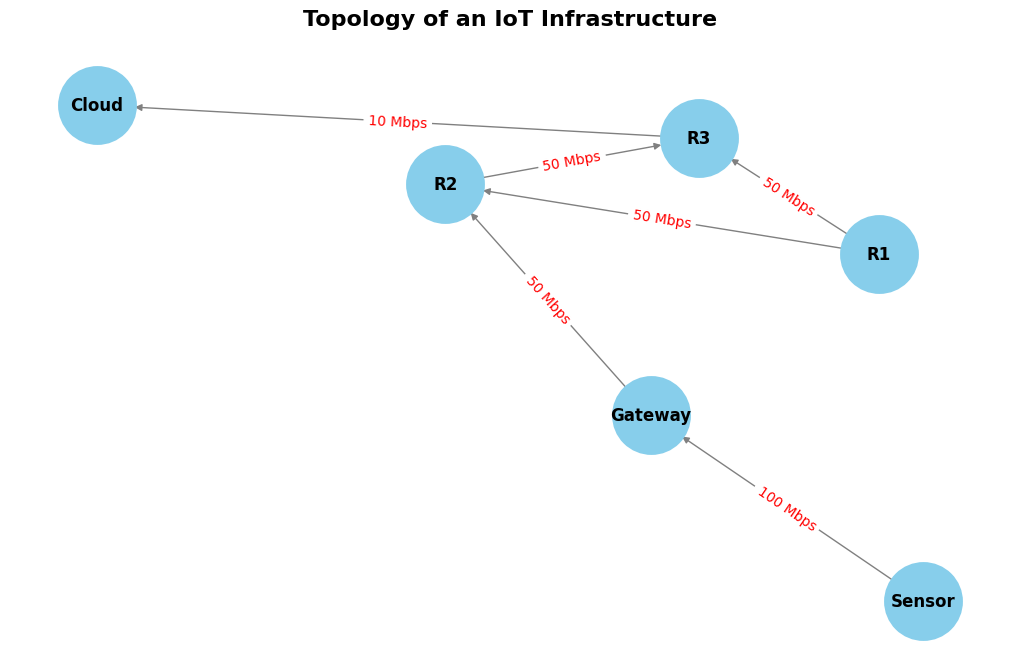

In [10]:
import networkx as nx
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

pos = nx.spring_layout(infra, seed=42) 


nx.draw(
    infra, 
    pos, 
    with_labels=True, 
    node_color='skyblue', 
    node_size=3000, 
    font_size=12, 
    font_weight='bold', 
    edge_color='gray',
    linewidths=2
)

edge_labels = nx.get_edge_attributes(infra, 'bandwidth_mbps')
if edge_labels:
    formatted_labels = {edge: f"{bw} Mbps" for edge, bw in edge_labels.items()}
    nx.draw_networkx_edge_labels(infra, pos, edge_labels=formatted_labels, font_color='red')

plt.title("Topology of an IoT Infrastructure", fontsize=16, fontweight='bold', pad=20)
plt.axis('off')
plt.show()

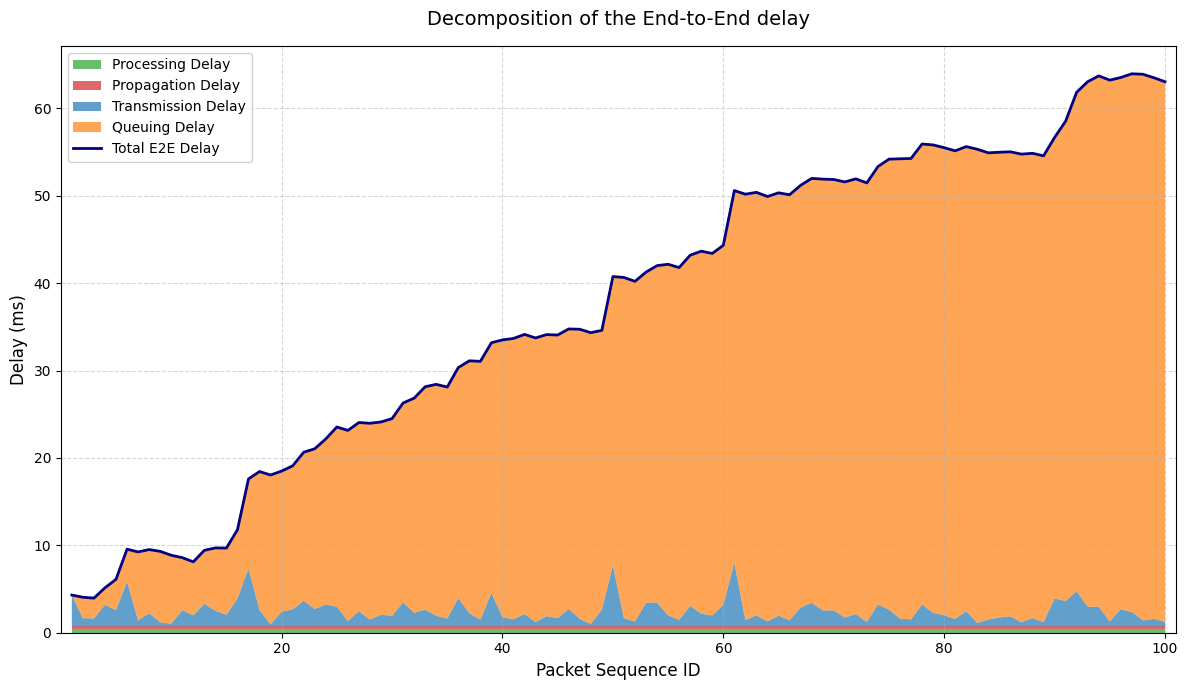


Breakdown of the last packet (ID 100):
- Processing:   0.40 ms
- Propagation:  0.33 ms
- Transmission: 0.50 ms
- Queuing:      61.83 ms
--------------------------------
= TOTAL:        63.06 ms


In [11]:
import matplotlib.pyplot as plt

# Helper function to sum a specific metric across all hops of a packet
def sum_metric_all_hops(hops_list, metric_name):
    if not isinstance(hops_list, list): return 0.0
    return sum(getattr(hop, metric_name, 0.0) for hop in hops_list)

df = df_results 

# Find automatically the name of the hops column
hops = 'Hops' if 'Hops' in df.columns else 'Hops_Details'

# Creation of new columns with the sum of each metric across all hops
df['Total_Proc_ms'] = df[hops].apply(lambda x: sum_metric_all_hops(x, 'processing_ms'))
df['Total_Prop_ms'] = df[hops].apply(lambda x: sum_metric_all_hops(x, 'propagation_ms'))
df['Total_Trans_ms'] = df[hops].apply(lambda x: sum_metric_all_hops(x, 'transmission_ms'))
df['Total_Queue_ms'] = df[hops].apply(lambda x: sum_metric_all_hops(x, 'queue_ms'))

# Creation of the graph
plt.figure(figsize=(12, 7))

# Create the stackplot for the breakdown of delays
plt.stackplot(
    df['Packet_ID'],
    df['Total_Proc_ms'],
    df['Total_Prop_ms'],
    df['Total_Trans_ms'],
    df['Total_Queue_ms'],
    labels=['Processing Delay', 'Propagation Delay', 'Transmission Delay', 'Queuing Delay'],
    colors=['#2ca02c', '#d62728', '#1f77b4', '#ff7f0e'], 
    alpha=0.7
)

# Upper line to mark the Total E2E Delay
plt.plot(df['Packet_ID'], df['Total_Delay_ms'], color='navy', linewidth=2, label='Total E2E Delay')

plt.title("Decomposition of the End-to-End delay", fontsize=14, pad=15)
plt.xlabel("Packet Sequence ID", fontsize=12)
plt.ylabel("Delay (ms)", fontsize=12)
plt.legend(loc='upper left', framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.5)

plt.margins(x=0.01)
plt.tight_layout()

plt.show()

# Final print to show the breakdown of the last packet
last_pkt = df.iloc[-1]
print(f"\nBreakdown of the last packet (ID {last_pkt['Packet_ID']}):")
print(f"- Processing:   {last_pkt['Total_Proc_ms']:.2f} ms")
print(f"- Propagation:  {last_pkt['Total_Prop_ms']:.2f} ms")
print(f"- Transmission: {last_pkt['Total_Trans_ms']:.2f} ms")
print(f"- Queuing:      {last_pkt['Total_Queue_ms']:.2f} ms")
print(f"--------------------------------")
print(f"= TOTAL:        {last_pkt['Total_Delay_ms']:.2f} ms")